# 09 - False-Alarm Justification

Purpose:
- for each cooled Gold alarm that is **not** followed by a `var_breach`,
  `portfolio_vol_spike`, or `drawdown_event` with `lead_days >= 1` (strictly *after* the
  alarm) within the 30-day lookback - Steps 07-08's early-warning-only "false alarm"
  definition, recomputed here from `outputs/step06/dashboard_metrics.csv` and restricted to
  `alarm_date >= ALL_SIGNALS_LIVE_START` (2012-01-26, Step 08) - identify which signal
  family (or families) triggered it;
- for alarms triggered by the relationship family, identify which cross-market correlation
  (`r_Brent`, `r_DXY`, `d_VIX`, `d_US10Y`) actually broke down;
- check whether the Brent-only baseline (Step 07) was simultaneously quiet, i.e. whether
  these alarms reflect Gold/macro-specific signal rather than a missed Brent shock;
- break the false alarms down by trigger family and by year to see whether they cluster in
  recognisable macro regimes.

Core framing:
The ~38% early-warning false-alarm rate (60 of 158 cooled Gold alarms fired since
`ALL_SIGNALS_LIVE_START = 2012-01-26`, using Steps 07-08's `lead_days >= 1` definition)
sounds high in isolation, but "false" only means "no portfolio-level VaR breach, vol spike,
or drawdown event occurred *strictly after* the alarm within 30 days" - it does not mean the
underlying signal was noise. This notebook digs into what each false alarm actually
reflects.

## Reader Orientation

This notebook does not change the alarm logic, but it refreshes Step 06's false-alarm
bookkeeping to match the early-warning-only definition introduced in Step 07 and adopted by
Step 08: a cooled Gold alarm counts as a false alarm only if no `var_breach`,
`portfolio_vol_spike`, or `drawdown_event` occurs with `lead_days >= 1` (strictly *after* the
alarm date) within the `LOOKBACK_DAYS = 30` window - a same-day coincidence
(`lead_days == 0`) is no longer enough to make an alarm "justified". The false-alarm table is
recomputed here directly from `outputs/step06/dashboard_metrics.csv`
(`cooled_gold_alarm`, `var_breach`, `portfolio_vol_spike`, `drawdown`) rather than read from
`outputs/step06/false_alarm_table.csv`, which still uses the old `lead_days >= 0` rule.

The analysis is also restricted to `alarm_date >= ALL_SIGNALS_LIVE_START` (2012-01-26, Step
08) - the date from which all seven Gold-alarm signal z-scores (including `gold_residual_z`
and the four `gold_corr_*_z` correlation signals) are live. Without this restriction, the 9
cooled alarms fired between 2011-04-06 and 2012-01-26 would all be misclassified as
`return_or_vol+relationship` triggers below, since `residual_alarm` could not yet be
computed for them.

This gives **60 false alarms out of 158 live cooled alarms (37.97%)**, which are then
cross-referenced against the per-day signal components (`gold_alarm_frame.parquet`,
`gold_signal_components.parquet`) and the Brent-only baseline (`brent_baseline_alarm.parquet`,
Step 07) to characterise each one.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step09"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD = 2.0
LOOKBACK_DAYS = 30
ALL_SIGNALS_LIVE_START = pd.Timestamp("2012-01-26")

In [2]:
dashboard_metrics_path = ROOT / "outputs" / "step06" / "dashboard_metrics.csv"
gold_alarm_frame_path = PROCESSED_DIR / "gold_alarm_frame.parquet"
gold_signal_components_path = PROCESSED_DIR / "gold_signal_components.parquet"
brent_baseline_alarm_path = PROCESSED_DIR / "brent_baseline_alarm.parquet"

for path in [dashboard_metrics_path, gold_alarm_frame_path, gold_signal_components_path, brent_baseline_alarm_path]:
    if not path.exists():
        raise FileNotFoundError(f"Required input not found: {path}")

dashboard_metrics = pd.read_csv(dashboard_metrics_path, index_col=0, parse_dates=True)
gold_alarm_frame = pd.read_parquet(gold_alarm_frame_path)
gold_signal_components = pd.read_parquet(gold_signal_components_path)
brent_baseline_alarm = pd.read_parquet(brent_baseline_alarm_path)


def event_starts(flag: pd.Series) -> pd.DatetimeIndex:
    flag = flag.fillna(0).astype(int)
    starts = flag.eq(1) & flag.shift(1, fill_value=0).eq(0)
    return pd.DatetimeIndex(flag.index[starts])


alarm_dates = event_starts(dashboard_metrics["cooled_gold_alarm"])
event_families = {
    "var_breach": event_starts(dashboard_metrics["var_breach"]),
    "portfolio_vol_spike": event_starts(dashboard_metrics["portfolio_vol_spike"]),
    "drawdown_event": event_starts((dashboard_metrics["drawdown"] <= -0.05).astype(int)),
}
all_event_dates = pd.DatetimeIndex(sorted(set().union(*[set(v) for v in event_families.values()])))

# Early-warning-only false-alarm definition (Steps 07-08): a cooled alarm only counts as
# "followed by an event" if some event occurs with lead_days >= 1, i.e. strictly AFTER the
# alarm. Same-day coincidences (lead_days == 0) no longer rescue an alarm from being
# classified as false.
followed_by_event = []
for alarm_date in alarm_dates:
    future_events = all_event_dates[
        (all_event_dates > alarm_date)
        & (all_event_dates <= alarm_date + pd.Timedelta(days=LOOKBACK_DAYS))
    ]
    followed_by_event.append(len(future_events) > 0)

false_alarm_table = pd.DataFrame({"followed_by_event": followed_by_event}, index=alarm_dates)
false_alarm_table.index.name = "alarm_date"

# Restrict to alarms fired once all seven Gold-alarm signal z-scores are live (Step 08), so
# the trigger-family / relationship-driver breakdowns below aren't biased by families
# (residual_alarm, gold_corr_*_z) that couldn't yet be computed.
false_alarm_table = false_alarm_table.loc[false_alarm_table.index >= ALL_SIGNALS_LIVE_START]
false_alarms = false_alarm_table.loc[~false_alarm_table["followed_by_event"]].copy()

print(f"Total cooled Gold alarms since {ALL_SIGNALS_LIVE_START.date()}:", len(false_alarm_table))
print(f"False alarms (no event with lead_days>=1 within {LOOKBACK_DAYS} days):", len(false_alarms))
print(f"False alarm rate: {len(false_alarms) / len(false_alarm_table):.2%}")
false_alarms.head()

Total cooled Gold alarms since 2012-01-26: 158
False alarms (no event with lead_days>=1 within 30 days): 60
False alarm rate: 37.97%


,followed_by_event
alarm_date,
2012-04-04,False
2013-02-26,False
2013-04-12,False
2013-04-25,False
2013-06-20,False


## Join False Alarms To Triggering Signal Families

Each Gold alarm fires when at least 2 of 3 signal families cross `|z| > THRESHOLD`:
`return_or_vol_alarm`, `residual_alarm`, `relationship_alarm`. Joining the false-alarm dates
to `gold_alarm_frame` recovers which families were active on each false-alarm day, summarised
as a `trigger_families` string.

In [3]:
family_flag_cols = ["return_or_vol_alarm", "residual_alarm", "relationship_alarm"]
family_names = {
    "return_or_vol_alarm": "return_or_vol",
    "residual_alarm": "residual",
    "relationship_alarm": "relationship",
}

false_alarms = false_alarms.join(gold_alarm_frame[family_flag_cols + ["alarm_score"]])


def trigger_families_str(row):
    return "+".join(family_names[c] for c in family_flag_cols if row[c] == 1)


false_alarms["trigger_families"] = false_alarms.apply(trigger_families_str, axis=1)

trigger_family_counts = false_alarms["trigger_families"].value_counts()
trigger_family_counts

trigger_families
return_or_vol+residual                 27
return_or_vol+residual+relationship    14
return_or_vol+relationship             13
residual+relationship                   6
Name: count, dtype: int64

### Result Comment And Significance

All 60 false alarms involve at least 2 of the 3 signal families (by construction, since the
Gold alarm requires `alarm_score >= 2`). The breakdown is:

- **return_or_vol + residual**: 27 (45.0%)
- **return_or_vol + residual + relationship** (all three families): 14 (23.3%)
- **return_or_vol + relationship**: 13 (21.7%)
- **residual + relationship**: 6 (10.0%)

`return_or_vol_alarm` participates in 54/60 (90.0%) of false alarms, `residual_alarm` in
47/60 (78.3%), and `relationship_alarm` in 33/60 (55.0%). Notably, **23.3% of false alarms
have all three families active simultaneously** (`alarm_score == 3`, the highest-confidence
reading the dashboard can produce) and still were not followed by a portfolio-level event on
an early-warning basis within 30 days. This rules out the simplest explanation for the ~38%
false-alarm rate - that it is driven by marginal, single-family, borderline triggers - since
no false alarm is a single-family trigger and almost a quarter are maximal-confidence
triggers.

## Relationship-Alarm Drivers

For false alarms where `relationship_alarm == 1`, the relationship family fires when at least
one of Gold's rolling correlations with `r_Brent`, `r_DXY`, `d_VIX`, or `d_US10Y` moves more
than `THRESHOLD` standard deviations from its own trailing mean (`gold_corr_*_z` in
`gold_signal_components.parquet`). Identifying which correlation(s) crossed the threshold on
each false-alarm day shows what kind of cross-market relationship shift is being flagged.

In [4]:
corr_z_cols = [
    "gold_corr_r_Brent_z",
    "gold_corr_r_DXY_z",
    "gold_corr_d_VIX_z",
    "gold_corr_d_US10Y_z",
]

false_alarms = false_alarms.join(gold_signal_components[corr_z_cols])


def relationship_drivers_str(row):
    if row["relationship_alarm"] != 1:
        return ""
    drivers = [
        c.replace("gold_corr_", "").replace("_z", "")
        for c in corr_z_cols
        if abs(row[c]) > THRESHOLD
    ]
    return "+".join(drivers)


false_alarms["relationship_drivers"] = false_alarms.apply(relationship_drivers_str, axis=1)

relationship_alarms = false_alarms.loc[false_alarms["relationship_alarm"] == 1]
print("False alarms with relationship_alarm == 1:", len(relationship_alarms))
relationship_alarms["relationship_drivers"].value_counts()

False alarms with relationship_alarm == 1: 33


relationship_drivers
d_US10Y                  9
r_DXY                    6
d_VIX                    6
d_VIX+d_US10Y            6
r_Brent                  2
r_Brent+d_VIX+d_US10Y    1
r_DXY+d_VIX              1
r_Brent+d_VIX            1
r_Brent+d_US10Y          1
Name: count, dtype: int64

### Result Comment And Significance

Of the 33 false alarms with `relationship_alarm == 1`, the threshold-crossing correlation(s)
are dominated by **`d_US10Y`** (17/33, 51.5%) and **`d_VIX`** (15/33, 45.5%), versus
**`r_DXY`** in 7/33 (21.2%) and **`r_Brent`** in only 5/33 (15.2%). 23 of 33 (69.7%) involve
a single driver; the remaining 10 (30.3%) involve two or three correlations breaking down
together.

This is an important result for the false-alarm discussion: when the *relationship* family
fires on a false-alarm day, it is overwhelmingly because **Gold's rolling correlation with
US 10-year yields or the VIX** has shifted abnormally - i.e. a change in gold's role as a
rates-sensitive or safe-haven asset - rather than a breakdown in Gold's (already weak)
relationship with `r_Brent`. These are genuine, economically interpretable signals about
gold's macro positioning; they are simply not the kind of signal that a Brent-heavy
portfolio's VaR, volatility, or drawdown metric would be expected to register, on an
early-warning basis, within 30 days.

## Concurrent Brent Baseline Check

If the Brent-only baseline (Step 07) was *also* alarming on a given false-alarm day, the
day was a genuinely abnormal day for the underlying commodity itself - not just for Gold's
relationships. If the Brent baseline was quiet, the false alarm reflects something specific
to Gold or to Gold's macro relationships (rates, USD, risk sentiment) that did not show up as
an extreme day for Brent.

In [5]:
false_alarms = false_alarms.join(brent_baseline_alarm[["brent_alarm"]])
false_alarms["brent_baseline_concurrent"] = false_alarms["brent_alarm"].fillna(0).astype(int)

overall_concurrent_rate = false_alarms["brent_baseline_concurrent"].mean()

trigger_breakdown = (
    false_alarms.groupby("trigger_families")
    .agg(
        false_alarm_count=("alarm_score", "size"),
        avg_alarm_score=("alarm_score", "mean"),
        brent_concurrent_rate=("brent_baseline_concurrent", "mean"),
    )
    .sort_values("false_alarm_count", ascending=False)
)
trigger_breakdown["pct_of_false_alarms"] = (
    trigger_breakdown["false_alarm_count"] / len(false_alarms)
).round(3)

print(f"Overall Brent-baseline concurrence rate: {overall_concurrent_rate:.3f}")
trigger_breakdown

Overall Brent-baseline concurrence rate: 0.117


,false_alarm_count,avg_alarm_score,brent_concurrent_rate,pct_of_false_alarms
trigger_families,,,,
return_or_vol+residual,27,2.0,0.111111,0.450
return_or_vol+residual+relationship,14,3.0,0.071429,0.233
return_or_vol+relationship,13,2.0,0.153846,0.217
residual+relationship,6,2.0,0.166667,0.100


### Result Comment And Significance

Across all 60 false alarms, the Brent-only baseline (Step 07) was simultaneously alarming on
**7 days (11.7%)** - up from 3.7% (2/54) under the old lookback-only definition. By
trigger-family combination, concurrence is 16.7% for `residual+relationship` (1/6), 15.4%
for `return_or_vol+relationship` (2/13), 11.1% for `return_or_vol+residual` (3/27), and 7.1%
for `return_or_vol+residual+relationship` (1/14).

The increase is mechanical and itself informative: the 6 false alarms newly reclassified by
the `lead_days >= 1` refinement are days where the Gold alarm coincided *with*, rather than
preceded, a portfolio event - and 5 of those 6 days are also days the Brent baseline was
alarming. That makes sense: a same-day coincidence between a Gold alarm and a portfolio event
is more likely to be a day when the underlying commodity itself was also moving sharply.

Even so, **88.3% of Gold's false alarms occur on days when Brent itself was not having an
extreme return/volatility day**. Combined with the previous result, this builds a consistent
picture: the large majority of these alarms are not "almost right" early warnings of a Brent
shock that simply failed to materialise - they are signals of genuine abnormality in Gold's
own price/volatility behaviour or in its correlation with macro variables (US10Y, VIX, DXY)
that is largely decoupled from Brent's day-to-day extremes. From an early-warning
portfolio-VaR standpoint they are "false," but from a market-signal standpoint most of them
are real and informative.

## False Alarms By Year

Grouping false alarms by calendar year shows whether they cluster in particular macro
regimes (e.g. Fed hiking/taper cycles, USD strength episodes) rather than being spread evenly
across the sample.

,false_alarm_count,brent_concurrent_rate
year,,
2012,1,0.000000
2013,8,0.125000
2014,1,1.000000
2015,3,0.000000
2016,3,0.333333
2017,4,0.000000
2018,6,0.166667
2019,6,0.166667
2020,2,0.500000


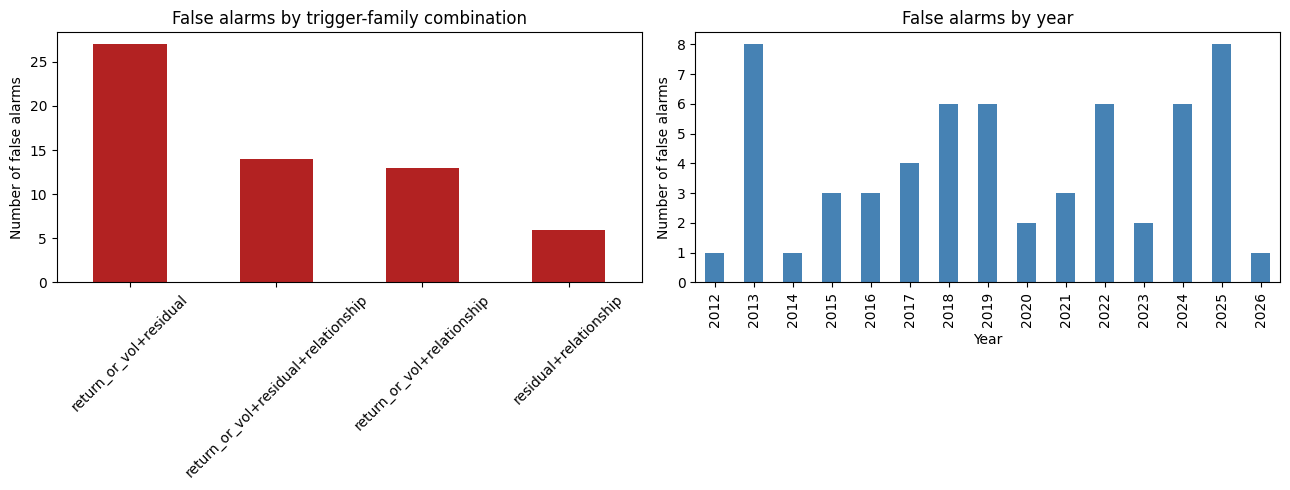

In [6]:
false_alarms["year"] = false_alarms.index.year

by_year = (
    false_alarms.groupby("year")
    .agg(
        false_alarm_count=("alarm_score", "size"),
        brent_concurrent_rate=("brent_baseline_concurrent", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

trigger_breakdown["false_alarm_count"].plot(kind="bar", ax=axes[0], color="firebrick")
axes[0].set_title("False alarms by trigger-family combination")
axes[0].set_ylabel("Number of false alarms")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

by_year["false_alarm_count"].plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("False alarms by year")
axes[1].set_ylabel("Number of false alarms")
axes[1].set_xlabel("Year")

plt.tight_layout()

by_year

### Result Comment And Significance

The 60 false alarms span **all 15 years** from 2012 (when all Gold-alarm signal families
become live) through the partial 2026 sample - no year in the live window is free of a false
alarm. They remain heavily concentrated: **2013 (8), 2018 (6), 2019 (6), 2022 (6), 2024 (6),
and 2025 (8) together account for 40/60 (66.7%)** of all false alarms - the same six
regime-transition years identified under the old definition (2013 "taper tantrum", 2018-2019
hiking-cycle peak/pivot and trade war, 2022 aggressive hiking cycle, 2024-2025
rate-cut-speculation period of record gold prices), each up by exactly one false alarm under
the `lead_days >= 1` refinement.

**2014** - the year of the Brent oil-price collapse - now contributes **exactly one** false
alarm (2014-01-02), versus zero under the old lookback-only definition. This single case is
also the only year with a **100% Brent-concurrence rate** (1/1): the 2014-01-02 alarm
coincided with a day the Brent baseline was also alarming, and simply was not followed by a
*further* portfolio event within 30 days. So 2014 still fits the original story - its Gold
alarms were genuinely tied to real, contemporaneous market moves, not noise.

Brent-baseline concurrence is now non-zero in seven years - 2013 (12.5%, 1/8), 2014 (100%,
1/1), 2016 (33.3%, 1/3), 2018 (16.7%, 1/6), 2019 (16.7%, 1/6), 2020 (50.0%, 1/2), and 2021
(33.3%, 1/3) - up from just 2016 and 2021 under the old definition. Five of these seven
concurrent days are exactly the newly-reclassified same-day alarms, consistent with the
mechanism described above.

## Step 09 Working Takeaways

- **The ~38.0% early-warning false-alarm rate (60/158 cooled alarms since
  `ALL_SIGNALS_LIVE_START = 2012-01-26`, using the `lead_days >= 1` definition from Steps
  07-08) is not driven by marginal triggers.** Every false alarm involves at least 2 of 3
  signal families, and 23.3% (14/60) involve all three (`alarm_score == 3`) - the
  dashboard's highest-confidence reading - yet still were not followed by a portfolio event
  with `lead_days >= 1` within 30 days.
- **88.3% of false alarms occur while the Brent-only baseline (Step 07) is quiet** (down
  from 96.3% under the old lookback-only definition - the 6 newly-reclassified false alarms
  are disproportionately Brent-concurrent, since they are same-day coincidences with real
  events rather than genuine misses). Most of Gold's false alarms are still not failed early
  warnings of an imminent Brent shock; they reflect abnormality in Gold's own behaviour or
  its macro relationships that is largely decoupled from Brent's day-to-day extremes.
- **When the relationship family drives a false alarm, the broken correlation is mostly
  Gold-vs-US10Y (51.5%) or Gold-vs-VIX (45.5%), not Gold-vs-Brent (15.2%).** These alarms
  capture genuine shifts in gold's role as a rates/safe-haven asset - signals a
  Brent-centric portfolio-risk metric is not designed to act on, on an early-warning basis.
- **False alarms cluster in regime-transition years** (2013, 2018-2019, 2022, 2024-2025 =
  66.7% of all false alarms) but occur in **every year** of the live sample (2012-2026),
  including 2014 (the Brent oil-price-collapse year) - though that single 2014 case is
  itself a same-day Brent-concurrent coincidence, not a genuine miss.
- **Overall verdict**: the false-alarm rate is best understood as the cost of using Gold to
  monitor a *broader* macro-relationship signal (rates, USD, risk sentiment) on top of its
  narrower Brent-relevant signal, evaluated on a strict early-warning (`lead_days >= 1`)
  basis. That cost is concentrated in calmer, regime-transition periods; even the lone 2014
  false alarm - the year most directly tied to a real Brent shock - was a same-day
  coincidence rather than a failed early warning. This supports the case that these "false"
  alarms carry genuine information, even if it is not information the current early-warning
  portfolio-risk metrics are built to use.

In [7]:
false_alarm_classification = false_alarms.reset_index().rename(columns={"index": "alarm_date"})
false_alarm_classification.to_csv(OUTPUT_DIR / "false_alarm_classification.csv", index=False)
trigger_breakdown.to_csv(OUTPUT_DIR / "false_alarm_trigger_breakdown.csv")
by_year.to_csv(OUTPUT_DIR / "false_alarm_by_year.csv")

print("Saved Step 09 false-alarm justification outputs to:", OUTPUT_DIR)

Saved Step 09 false-alarm justification outputs to: C:\Users\shrut\OneDrive - Singapore Management University\SMU Master's in Quantitative Finance\Sem3\QF637 Commodities Risk Management\Commonds Projects\qf637\outputs\step09
